# 1. Data Loading and Initial Exploration

This section loads the annual housing and economic dataset and performs an initial assessment of its structure, coverage, data types, and completeness.

In [2]:
import pandas as pd
from daytascape_db_core.connection import get_db_engine

In [3]:
engine = get_db_engine()

query = """
SELECT *
FROM annual_housing_economic_data
ORDER BY year, region;
"""

df = pd.read_sql(query, engine)

df.shape

(841, 7)

### 1.2 Dataset Structure

In [4]:
df.head()

,year,region,nhpi,median_after_tax_income,population,housing_starts_saar,policy_rate
0,1946,Canada,NaN,NaN,12393000,NaN,NaN
1,1947,Canada,NaN,NaN,12646000,NaN,NaN
2,1948,Canada,NaN,NaN,12930000,NaN,NaN
3,1949,Canada,NaN,NaN,13548000,NaN,NaN
4,1950,Canada,NaN,NaN,13807000,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 841 entries, 0 to 840
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     841 non-null    int64  
 1   region                   841 non-null    str    
 2   nhpi                     447 non-null    float64
 3   median_after_tax_income  539 non-null    float64
 4   population               841 non-null    int64  
 5   housing_starts_saar      407 non-null    float64
 6   policy_rate              187 non-null    float64
dtypes: float64(4), int64(2), str(1)
memory usage: 46.1 KB


In [6]:
df.dtypes

year                         int64
region                         str
nhpi                       float64
median_after_tax_income    float64
population                   int64
housing_starts_saar        float64
policy_rate                float64
dtype: object

### 1.3 Dataset Coverage

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 841
Columns: 7


In [8]:
df["region"].unique()
df["region"].nunique()

11

In [9]:
print("Start year:", df["year"].min())
print("End year:", df["year"].max())

Start year: 1946
End year: 2026


### 1.4 Missing Data Assessment

Missing values are assessed to determine the availability of each variable across the historical dataset and to identify limitations that need to be considered during the analysis.

In [10]:
missing = df.isna().sum()

missing

year                         0
region                       0
nhpi                       394
median_after_tax_income    302
population                   0
housing_starts_saar        434
policy_rate                654
dtype: int64

In [11]:
missing_pct = (df.isna().mean() * 100).round(2)
missing_pct

year                        0.00
region                      0.00
nhpi                       46.85
median_after_tax_income    35.91
population                  0.00
housing_starts_saar        51.61
policy_rate                77.76
dtype: float64

In [12]:
missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_summary

,missing_count,missing_pct
year,0,0.00
region,0,0.00
nhpi,394,46.85
median_after_tax_income,302,35.91
population,0,0.00
housing_starts_saar,434,51.61
policy_rate,654,77.76


### 1.5 Interpretation

The dataset contains 841 observations across 11 regions and covers the period from 1946 to 2026. Population and geographic identifiers are complete across the dataset, while the availability of the other economic and housing indicators varies substantially over time.

The missing-data assessment is important because the main analysis focuses on the period where the required housing, income, price, population, and policy variables are available consistently.

# 2. Data Coverage and Regional Overview

This section examines the availability of the main indicators across regions and years. It also provides an overview of the regional distribution of housing prices, income, population, housing supply, and policy rates.

### 2.1 Regional Data Coverage

The dataset contains observations for Canada and the ten provinces. Coverage varies across indicators because the underlying source series begin and end in different years.

In [13]:
coverage = (
    df.groupby("region")
    .agg(
        first_year=("year", "min"),
        last_year=("year", "max"),
        nhpi_obs=("nhpi", "count"),
        income_obs=("median_after_tax_income", "count"),
        population_obs=("population", "count"),
        housing_supply_obs=("housing_starts_saar", "count"),
        policy_rate_obs=("policy_rate", "count")
    )
    .reset_index()
)

coverage

,region,first_year,last_year,nhpi_obs,income_obs,population_obs,housing_supply_obs,policy_rate_obs
0,Alberta,1951,2026,41,49,76,37,17
1,British Columbia,1951,2026,41,49,76,37,17
2,Canada,1946,2026,46,49,81,37,17
3,Manitoba,1951,2026,41,49,76,37,17
4,New Brunswick,1951,2026,41,49,76,37,17
5,Newfoundland and Labrador,1951,2026,41,49,76,37,17
6,Nova Scotia,1951,2026,41,49,76,37,17
7,Ontario,1951,2026,41,49,76,37,17
8,Prince Edward Island,1951,2026,32,49,76,37,17
9,Quebec,1951,2026,41,49,76,37,17


### 2.2 Coverage Findings

- Population data are complete across all regions for the available period.
- Income data have consistent regional coverage through 2024.
- NHPI coverage is consistent across most regions, with shorter coverage for Prince Edward Island.
- Housing supply has consistent regional coverage from 1990 onward.
- Policy-rate observations begin in 2010 and provide 17 annual observations for each region.
- Missing values are primarily associated with differences in the historical coverage of the underlying source series rather than random missing observations.

### 2.3 Regional Overview

Average values are calculated by region to provide a high-level comparison of housing prices, income, population, housing supply, and policy rates across the dataset.

In [14]:
regional_summary = df.groupby("region").agg(
    avg_nhpi=("nhpi", "mean"),
    avg_income=("median_after_tax_income", "mean"),
    avg_population=("population", "mean"),
    avg_housing_starts=("housing_starts_saar", "mean"),
    avg_policy_rate=("policy_rate", "mean")
).round(2)

regional_summary

,avg_nhpi,avg_income,avg_population,avg_housing_starts,avg_policy_rate
region,,,,,
Alberta,72.38,73369.39,2652487.83,30575.31,1.56
British Columbia,94.46,64900.00,3298021.68,33544.32,1.56
Canada,75.76,64951.02,26497516.28,196569.93,1.56
Manitoba,74.33,61440.82,1107456.16,5144.95,1.56
New Brunswick,92.34,57148.98,703439.00,3576.13,1.56
Newfoundland and Labrador,73.03,58234.69,521769.61,2161.20,1.56
Nova Scotia,82.73,56769.39,871757.39,4835.91,1.56
Ontario,78.74,70653.06,10175336.57,68583.17,1.56
Prince Edward Island,99.00,57155.10,129343.53,849.70,1.56


### 2.4 Interpretation

The regional overview shows substantial differences across provinces in housing prices, income, population, and housing supply. These differences provide the basis for the regional analysis later in the project.

The coverage analysis also establishes 2010–2024 as the common analytical period used for the main comparison of housing prices, income, population, housing supply, and policy rates.

# 3. Housing Price Analysis

This section examines changes in Canadian housing prices using the National House Price Index (NHPI). The analysis first calculates annual NHPI growth and then focuses on the national housing-price trend and periods of particularly strong or weak growth.

### 3.1 Annual NHPI Growth

Annual NHPI growth is calculated for each region to measure year-over-year changes in housing prices.

In [15]:
canada = df[df["region"] == "Canada"].copy()

canada[[
    "year",
    "nhpi",
    "median_after_tax_income",
    "population",
    "housing_starts_saar",
    "policy_rate"
]].tail(20)

,year,nhpi,median_after_tax_income,population,housing_starts_saar,policy_rate
623,2007,85.066667,67300.0,33001918,228377.75,NaN
634,2008,87.983333,68300.0,33372978,211130.08,NaN
645,2009,85.958333,68100.0,33758581,147968.00,NaN
656,2010,87.841667,67500.0,34132531,191564.08,0.590996
667,2011,89.733333,67200.0,34457713,193387.25,1.000000
678,2012,91.866667,69100.0,34834973,215411.00,1.000000
689,2013,93.466667,69500.0,35209597,188031.42,1.000000
700,2014,94.933333,71100.0,35555305,189107.67,1.000000
711,2015,96.208333,70900.0,35823591,193597.50,0.646552
722,2016,98.641667,70900.0,36257421,198168.25,0.500000


In [16]:
nhpi_analysis = df[
    ["year", "region", "nhpi"]
].copy()

In [17]:
nhpi_analysis["nhpi_growth_pct"] = (
    nhpi_analysis
    .groupby("region")["nhpi"]
    .pct_change(fill_method=None)
    * 100
)

### 3.2 National NHPI Trend

The national NHPI series is isolated to examine how Canadian housing prices have evolved over time.

In [18]:
canada_nhpi = nhpi_analysis[
    nhpi_analysis["region"] == "Canada"
].copy()

canada_nhpi.tail(20)

,year,region,nhpi,nhpi_growth_pct
623,2007,Canada,85.066667,7.747520
634,2008,Canada,87.983333,3.428683
645,2009,Canada,85.958333,-2.301572
656,2010,Canada,87.841667,2.190984
667,2011,Canada,89.733333,2.153496
678,2012,Canada,91.866667,2.377415
689,2013,Canada,93.466667,1.741655
700,2014,Canada,94.933333,1.569187
711,2015,Canada,96.208333,1.343048
722,2016,Canada,98.641667,2.529233


In [19]:
canada_nhpi["nhpi_growth_pct"].describe()

count    45.000000
mean      2.581102
std       4.312357
min      -6.845526
25%      -0.029691
50%       1.569187
75%       4.090209
max      13.804109
Name: nhpi_growth_pct, dtype: float64

### 3.3 Highest and Lowest NHPI Growth

The strongest and weakest annual NHPI growth rates are identified to highlight periods of significant housing-price appreciation and decline.

In [20]:
canada_nhpi.nsmallest(5, "nhpi_growth_pct")[
    ["year", "nhpi", "nhpi_growth_pct"]
]

,year,nhpi,nhpi_growth_pct
447,1991,56.133333,-6.845526
359,1983,37.875000,-3.277293
645,2009,85.958333,-2.301572
348,1982,39.158333,-2.124557
502,1996,55.158333,-1.955266


In [21]:
canada_nhpi.nlargest(5, "nhpi_growth_pct")[
    ["year", "nhpi", "nhpi_growth_pct"]
]

,year,nhpi,nhpi_growth_pct
403,1987,47.541667,13.804109
425,1989,59.383333,13.236930
777,2021,116.175000,10.318905
414,1988,52.441667,10.306748
612,2006,78.950000,9.767119


### 3.4 NHPI Growth Distribution

In [22]:
canada_nhpi["nhpi_growth_pct"].describe()

count    45.000000
mean      2.581102
std       4.312357
min      -6.845526
25%      -0.029691
50%       1.569187
75%       4.090209
max      13.804109
Name: nhpi_growth_pct, dtype: float64

### 3.5 National NHPI Trend

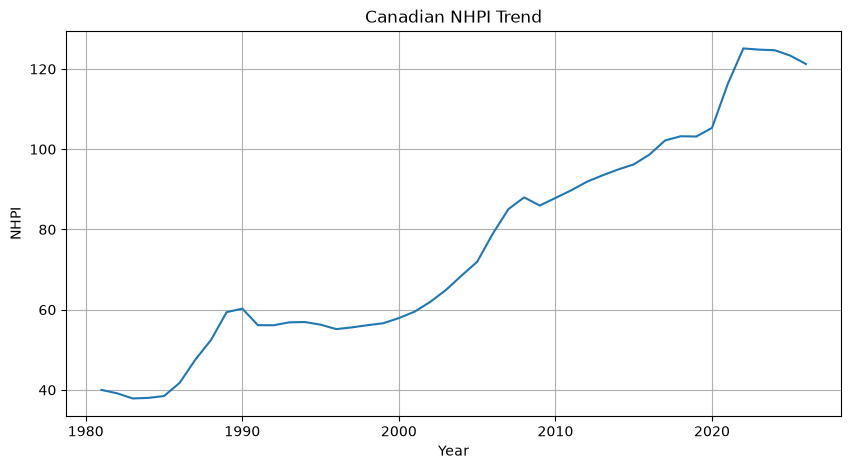

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    canada_nhpi["year"],
    canada_nhpi["nhpi"]
)

plt.title("Canadian NHPI Trend")
plt.xlabel("Year")
plt.ylabel("NHPI")
plt.grid(True)

plt.show()

### 3.6 Interpretation

The national NHPI analysis shows substantial variation in annual housing-price growth over the historical period. The average annual NHPI growth was 2.58%, while the median was 1.57%.

The strongest annual increase in the national series occurred in 1987 at 13.80%, followed by 1989 at 13.24%. More recently, 2021 recorded a strong annual increase of 10.32%.

The weakest annual growth occurred in 1991, when the NHPI declined by 6.85%. Other notable declines occurred in 1983 and 2009.

In [24]:
canada_nhpi.sort_values(
    "nhpi_growth_pct",
    ascending=False
)[["year", "nhpi", "nhpi_growth_pct"]].head(10)

,year,nhpi,nhpi_growth_pct
403,1987,47.541667,13.804109
425,1989,59.383333,13.236930
777,2021,116.175000,10.318905
414,1988,52.441667,10.306748
612,2006,78.950000,9.767119
392,1986,41.775000,8.576998
623,2007,85.066667,7.747520
788,2022,125.108333,7.689549
590,2004,68.483333,5.548420
601,2005,71.925000,5.025554


In [25]:
regional_nhpi = nhpi_analysis[
    nhpi_analysis["region"] != "Canada"
].copy()

regional_nhpi

,year,region,nhpi,nhpi_growth_pct
5,1951,Alberta,NaN,NaN
6,1951,British Columbia,NaN,NaN
8,1951,Manitoba,NaN,NaN
9,1951,New Brunswick,NaN,NaN
10,1951,Newfoundland and Labrador,NaN,NaN
...,...,...,...,...
836,2026,Nova Scotia,128.416667,1.388249
837,2026,Ontario,118.433333,-2.764094
838,2026,Prince Edward Island,123.700000,0.494212
839,2026,Quebec,149.650000,2.115319


In [26]:
regional_nhpi_summary = (
    regional_nhpi
    .groupby("region")["nhpi"]
    .mean()
    .sort_values(ascending=False)
)

regional_nhpi_summary

region
Prince Edward Island         99.001823
British Columbia             94.457927
New Brunswick                92.337602
Quebec                       83.659756
Nova Scotia                  82.730894
Ontario                      78.740447
Manitoba                     74.325813
Newfoundland and Labrador    73.026829
Alberta                      72.380081
Saskatchewan                 68.305285
Name: nhpi, dtype: float64

In [27]:
regional_nhpi_2010_2024 = regional_nhpi[
    regional_nhpi["year"].between(2010, 2024)
].copy()

In [28]:
regional_nhpi_2010_2024_summary = (
    regional_nhpi
    .groupby("region")["nhpi"]
    .mean()
    .sort_values(ascending=False)
)

regional_nhpi_2010_2024_summary

region
Prince Edward Island         99.001823
British Columbia             94.457927
New Brunswick                92.337602
Quebec                       83.659756
Nova Scotia                  82.730894
Ontario                      78.740447
Manitoba                     74.325813
Newfoundland and Labrador    73.026829
Alberta                      72.380081
Saskatchewan                 68.305285
Name: nhpi, dtype: float64

In [29]:
regional_nhpi_2010_2024["year"].min(), regional_nhpi_2010_2024["year"].max()

(np.int64(2010), np.int64(2024))

In [30]:
regional_nhpi_2010_2024.shape

(150, 4)

In [31]:
regional_nhpi_2010_2024.groupby("region").size()

region
Alberta                      15
British Columbia             15
Manitoba                     15
New Brunswick                15
Newfoundland and Labrador    15
Nova Scotia                  15
Ontario                      15
Prince Edward Island         15
Quebec                       15
Saskatchewan                 15
dtype: int64

In [32]:
regional_nhpi_2010_2024.groupby("region")["nhpi"].mean().sort_values(
    ascending=False
)

region
Quebec                       110.487778
Manitoba                     107.206667
British Columbia             106.751667
Prince Edward Island         105.789444
Nova Scotia                  104.328333
New Brunswick                104.223889
Ontario                      102.500000
Alberta                      102.022778
Newfoundland and Labrador     99.988333
Saskatchewan                  99.938889
Name: nhpi, dtype: float64

In [33]:
regional_nhpi_2010_2024.groupby("region")["nhpi"].agg(
    ["first", "last"]
)

,first,last
region,,
Alberta,92.491667,120.750000
British Columbia,97.150000,127.183333
Manitoba,82.458333,139.858333
New Brunswick,97.600000,119.925000
Newfoundland and Labrador,93.225000,106.566667
Nova Scotia,91.816667,121.091667
Ontario,80.783333,124.441667
Prince Edward Island,98.141667,122.600000
Quebec,93.425000,142.791667


In [34]:
regional_growth = (
    regional_nhpi_2010_2024
    .groupby("region")["nhpi"]
    .agg(["first", "last"])
)

regional_growth["growth_pct"] = (
    (regional_growth["last"] - regional_growth["first"])
    / regional_growth["first"]
) * 100

regional_growth.sort_values(
    "growth_pct",
    ascending=False
)

,first,last,growth_pct
region,,,
Manitoba,82.458333,139.858333,69.610915
Ontario,80.783333,124.441667,54.043738
Quebec,93.425000,142.791667,52.840960
Nova Scotia,91.816667,121.091667,31.884190
British Columbia,97.150000,127.183333,30.914394
Alberta,92.491667,120.750000,30.552302
Prince Edward Island,98.141667,122.600000,24.921457
New Brunswick,97.600000,119.925000,22.873975
Newfoundland and Labrador,93.225000,106.566667,14.311254


# 4. Housing Affordability

This section examines housing affordability by comparing annual housing-price growth with annual growth in median after-tax income across the provinces from 2010 to 2024.

In [35]:
income = pd.read_sql(
    """
    SELECT year, region, median_after_tax_income
    FROM income
    WHERE year BETWEEN 2010 AND 2024
      AND region <> 'Canada'
    ORDER BY region, year
    """,
    engine
)

income.head()

,year,region,median_after_tax_income
0,2010,Alberta,82800.0
1,2011,Alberta,82700.0
2,2012,Alberta,88400.0
3,2013,Alberta,90500.0
4,2014,Alberta,92000.0


In [36]:
income.shape

(150, 3)

In [37]:
income["region"].nunique()

10

In [38]:
income["year"].nunique()

15

In [39]:
income.isna().sum()

year                       0
region                     0
median_after_tax_income    0
dtype: int64

### 4.2 Income Growth

Annual income growth is calculated within each province to measure year-over-year changes in median after-tax income.

In [40]:
income["income_growth_pct"] = (
    income.groupby("region")["median_after_tax_income"]
    .pct_change()
    * 100
)

In [41]:
income.head(14)

,year,region,median_after_tax_income,income_growth_pct
0,2010,Alberta,82800.0,NaN
1,2011,Alberta,82700.0,-0.120773
2,2012,Alberta,88400.0,6.892382
3,2013,Alberta,90500.0,2.375566
4,2014,Alberta,92000.0,1.657459
5,2015,Alberta,93100.0,1.195652
6,2016,Alberta,89100.0,-4.296455
7,2017,Alberta,88500.0,-0.673401
8,2018,Alberta,87000.0,-1.694915
9,2019,Alberta,85300.0,-1.954023


In [42]:
income["income_growth_pct"].describe()

count    140.000000
mean       0.677979
std        3.081646
min       -8.395802
25%       -0.883572
50%        0.624576
75%        2.566439
max        8.682171
Name: income_growth_pct, dtype: float64

In [43]:
regional_nhpi_2010_2024.columns

Index(['year', 'region', 'nhpi', 'nhpi_growth_pct'], dtype='str')

In [44]:
regional_nhpi_2010_2024.head()

,year,region,nhpi,nhpi_growth_pct
654,2010,Alberta,92.491667,0.498008
655,2010,British Columbia,97.150000,2.596145
657,2010,Manitoba,82.458333,4.764426
658,2010,New Brunswick,97.600000,1.525659
659,2010,Newfoundland and Labrador,93.225000,5.947533


### 4.3 Housing Price and Income Growth

Housing-price growth and income growth are combined to determine whether housing prices are increasing faster or slower than incomes across provinces and years.

In [45]:
affordability = pd.merge(
    regional_nhpi_2010_2024,
    income,
    on=["year", "region"],
    how="inner"
)

In [46]:
affordability.head()

,year,region,nhpi,nhpi_growth_pct,median_after_tax_income,income_growth_pct
0,2010,Alberta,92.491667,0.498008,82800.0,NaN
1,2010,British Columbia,97.150000,2.596145,66500.0,NaN
2,2010,Manitoba,82.458333,4.764426,66100.0,NaN
3,2010,New Brunswick,97.600000,1.525659,60400.0,NaN
4,2010,Newfoundland and Labrador,93.225000,5.947533,61500.0,NaN


In [47]:
affordability.shape

(150, 6)

In [48]:
affordability.isna().sum()

year                        0
region                      0
nhpi                        0
nhpi_growth_pct             0
median_after_tax_income     0
income_growth_pct          10
dtype: int64

### 4.4 Affordability Gap

The affordability gap measures the difference between housing-price growth and income growth. A positive value indicates that housing prices grew faster than income, while a negative value indicates that income grew faster than housing prices.

In [49]:
affordability["affordability_gap_pct"] = (
    affordability["nhpi_growth_pct"] - affordability["income_growth_pct"]
)

In [50]:
affordability[
    ["year",
     "region",
     "nhpi_growth_pct",
     "income_growth_pct",
     "affordability_gap_pct"]
].head(20)

,year,region,nhpi_growth_pct,income_growth_pct,affordability_gap_pct
0,2010,Alberta,0.498008,NaN,NaN
1,2010,British Columbia,2.596145,NaN,NaN
2,2010,Manitoba,4.764426,NaN,NaN
3,2010,New Brunswick,1.525659,NaN,NaN
4,2010,Newfoundland and Labrador,5.947533,NaN,NaN
5,2010,Nova Scotia,0.906676,NaN,NaN
6,2010,Ontario,2.430262,NaN,NaN
7,2010,Prince Edward Island,-1.563022,NaN,NaN
8,2010,Quebec,3.118102,NaN,NaN
9,2010,Saskatchewan,3.954592,NaN,NaN


In [51]:
affordability["affordability_gap_pct"].describe()

count    140.000000
mean       1.453647
std        4.813334
min       -8.235975
25%       -1.311412
50%        0.331845
75%        3.259706
max       18.864673
Name: affordability_gap_pct, dtype: float64

### 4.5 Highest and Lowest Affordability Gaps

In [52]:
affordability.nlargest(
    10, "affordability_gap_pct"
)[
    [
        "year",
        "region",
        "nhpi_growth_pct",
        "income_growth_pct",
        "affordability_gap_pct"
    ]
]

,year,region,nhpi_growth_pct,income_growth_pct,affordability_gap_pct
122,2022,Manitoba,15.577001,-3.287671,18.864673
112,2021,Manitoba,14.791699,-0.409277,15.200976
118,2021,Quebec,14.590615,-0.143885,14.734500
123,2022,New Brunswick,7.020702,-7.048458,14.069160
120,2022,Alberta,12.015722,-0.355450,12.371172
125,2022,Nova Scotia,3.928315,-8.395802,12.324118
111,2021,British Columbia,10.898721,-1.028278,11.926998
117,2021,Prince Edward Island,13.249516,1.445087,11.804430
126,2022,Ontario,6.496503,-4.756098,11.252601
128,2022,Quebec,9.462003,-1.729107,11.191109


In [53]:
affordability.nsmallest(
    10, "affordability_gap_pct"
)[
    [
        "year",
        "region",
        "nhpi_growth_pct",
        "income_growth_pct",
        "affordability_gap_pct"
    ]
]

,year,region,nhpi_growth_pct,income_growth_pct,affordability_gap_pct
87,2018,Prince Edward Island,0.233081,8.469055,-8.235975
109,2020,Saskatchewan,-1.772500,5.241935,-7.014436
34,2013,Newfoundland and Labrador,1.766572,8.682171,-6.915598
20,2012,Alberta,1.265141,6.892382,-5.627241
101,2020,British Columbia,1.446556,6.868132,-5.421576
31,2013,British Columbia,-1.085258,4.166667,-5.251925
49,2014,Saskatchewan,1.938049,6.763926,-4.825877
104,2020,Newfoundland and Labrador,0.538324,5.320814,-4.782490
106,2020,Ontario,2.695825,7.358739,-4.662913
100,2020,Alberta,-0.917042,3.282532,-4.199574


### 4.6 Regional Affordability

In [54]:
regional_affordability = (
    affordability
    .groupby("region")["affordability_gap_pct"]
    .mean()
    .sort_values(ascending=False)
)

regional_affordability

region
Manitoba                     3.323826
Ontario                      2.540508
Quebec                       2.062649
Alberta                      1.725195
Nova Scotia                  1.447812
Prince Edward Island         1.161541
British Columbia             1.005694
New Brunswick                0.939985
Saskatchewan                 0.171736
Newfoundland and Labrador    0.157520
Name: affordability_gap_pct, dtype: float64

### 4.7 Interpretation

The affordability analysis shows that housing-price growth generally exceeded income growth across the provinces during the study period. The mean affordability gap was 1.45 percentage points, although the size and direction of the gap varied considerably across years and regions.

The largest observed gap occurred in Manitoba in 2022, when NHPI growth exceeded income growth by 18.86 percentage points. Manitoba also recorded the highest average affordability gap across the study period at 3.32 percentage points.

In contrast, negative affordability gaps occurred when income growth exceeded housing-price growth. The lowest observed gap was −8.24 percentage points in Prince Edward Island in 2018.

These results indicate that housing affordability pressures varied substantially across both provinces and years.

## 5. Population and Housing Supply

This section examines population growth and housing supply growth across the provinces from 2010 to 2024. The two measures are then combined to assess how changes in housing supply compare with changes in population.

### 5.1 Population

In [55]:
population = pd.read_sql(
    """
    SELECT year, region, population
    FROM population
    WHERE year BETWEEN 2010 AND 2024
      AND region <> 'Canada'
    ORDER BY region, year
    """,
    engine
)

In [56]:
population.shape

(150, 3)

In [57]:
population.head()

,year,region,population
0,2010,Alberta,3747235
1,2011,Alberta,3805071
2,2012,Alberta,3897746
3,2013,Alberta,4008421
4,2014,Alberta,4103702


### 5.2 Population Growth

Annual population growth is calculated within each province to measure year-over-year changes in population.

In [58]:
population["population_growth_pct"] = (
    population.groupby("region")["population"]
    .pct_change()
    * 100
)

population.head(15)

,year,region,population,population_growth_pct
0,2010,Alberta,3747235,NaN
1,2011,Alberta,3805071,1.543431
2,2012,Alberta,3897746,2.435566
3,2013,Alberta,4008421,2.839462
4,2014,Alberta,4103702,2.377021
5,2015,Alberta,4163048,1.446158
6,2016,Alberta,4207139,1.059104
7,2017,Alberta,4253530,1.102673
8,2018,Alberta,4311439,1.361434
9,2019,Alberta,4376860,1.517382


In [59]:
population["population_growth_pct"].describe()

count    140.000000
mean       1.294179
std        0.986040
min       -0.453408
25%        0.605888
50%        1.165720
75%        1.813365
max        4.311754
Name: population_growth_pct, dtype: float64

In [60]:
population.isna().sum()

year                      0
region                    0
population                0
population_growth_pct    10
dtype: int64

### 5.3 Highest and Lowest Population Growth

In [61]:
population.nlargest(
    10, "population_growth_pct"
)[
    ["year", "region", "population_growth_pct"]
]

,year,region,population_growth_pct
14,2024,Alberta,4.311754
118,2023,Prince Edward Island,4.282019
13,2023,Alberta,4.208036
103,2023,Ontario,3.388269
117,2022,Prince Edward Island,3.276073
28,2023,British Columbia,3.082375
58,2023,New Brunswick,2.904142
88,2023,Nova Scotia,2.872682
149,2024,Saskatchewan,2.849973
148,2023,Saskatchewan,2.849208


In [62]:
population.nsmallest(
    10, "population_growth_pct"
)[
    ["year", "region", "population_growth_pct"]
]

,year,region,population_growth_pct
70,2020,Newfoundland and Labrador,-0.453408
78,2013,Nova Scotia,-0.359238
108,2013,Prince Edward Island,-0.313721
68,2018,Newfoundland and Labrador,-0.231443
77,2012,Nova Scotia,-0.192242
79,2014,Nova Scotia,-0.136783
145,2020,Saskatchewan,-0.112056
69,2019,Newfoundland and Labrador,-0.091506
67,2017,Newfoundland and Labrador,-0.040538
48,2013,New Brunswick,-0.003824


### 5.4 Housing Supply

In [63]:
housing_supply = pd.read_sql(
    """
    SELECT year, region, housing_starts_saar
    FROM housing_supply
    WHERE year BETWEEN 2010 AND 2024
      AND region <> 'Canada'
    ORDER BY region, year
    """,
    engine
)

In [64]:
housing_supply.shape

(150, 3)

In [65]:
housing_supply.head()

,year,region,housing_starts_saar
0,2010,Alberta,27378.75
1,2011,Alberta,25543.17
2,2012,Alberta,33285.00
3,2013,Alberta,36111.83
4,2014,Alberta,40563.67


### 5.5 Housing Supply Growth

Annual housing supply growth is calculated within each province using year-over-year changes in housing starts.

In [66]:
housing_supply["housing_supply_growth_pct"] = (
    housing_supply.groupby("region")["housing_starts_saar"]
    .pct_change()
    * 100
)

In [67]:
housing_supply["housing_supply_growth_pct"].describe()

count    140.000000
mean       3.133023
std       20.408987
min      -41.284012
25%      -10.214195
50%        1.763589
75%       14.108133
max       76.483890
Name: housing_supply_growth_pct, dtype: float64

In [68]:
housing_supply.isna().sum()

year                          0
region                        0
housing_starts_saar           0
housing_supply_growth_pct    10
dtype: int64

In [69]:
housing_supply.columns

Index(['year', 'region', 'housing_starts_saar', 'housing_supply_growth_pct'], dtype='str')

### 5.6 Population and Housing Supply Comparison

Population growth and housing supply growth are combined to compare changes in housing supply with changes in population across provinces and years.

In [70]:
housing_demand_supply = pd.merge(
    population,
    housing_supply,
    on=["year", "region"],
    how="inner"
)

In [71]:
housing_demand_supply.shape

(150, 6)

In [72]:
housing_demand_supply.head()

,year,region,population,population_growth_pct,housing_starts_saar,housing_supply_growth_pct
0,2010,Alberta,3747235,NaN,27378.75,NaN
1,2011,Alberta,3805071,1.543431,25543.17,-6.704397
2,2012,Alberta,3897746,2.435566,33285.00,30.308807
3,2013,Alberta,4008421,2.839462,36111.83,8.492805
4,2014,Alberta,4103702,2.377021,40563.67,12.327927


### 5.7 Supply-Demand Growth Gap

The supply-demand growth gap is calculated as housing supply growth minus population growth. A positive value indicates that housing supply grew faster than population in that year, while a negative value indicates that population growth exceeded housing supply growth.

In [73]:
housing_demand_supply["supply_demand_growth_gap_pct"] = (
    housing_demand_supply["housing_supply_growth_pct"]
    - housing_demand_supply["population_growth_pct"]
)

In [74]:
housing_demand_supply.head(20)

,year,region,population,population_growth_pct,housing_starts_saar,housing_supply_growth_pct,supply_demand_growth_gap_pct
0,2010,Alberta,3747235,NaN,27378.75,NaN,NaN
1,2011,Alberta,3805071,1.543431,25543.17,-6.704397,-8.247828
2,2012,Alberta,3897746,2.435566,33285.00,30.308807,27.873241
3,2013,Alberta,4008421,2.839462,36111.83,8.492805,5.653343
4,2014,Alberta,4103702,2.377021,40563.67,12.327927,9.950906
5,2015,Alberta,4163048,1.446158,37520.50,-7.502206,-8.948363
6,2016,Alberta,4207139,1.059104,24619.08,-34.384990,-35.444093
7,2017,Alberta,4253530,1.102673,29321.83,19.102054,17.999381
8,2018,Alberta,4311439,1.361434,26272.50,-10.399521,-11.760955
9,2019,Alberta,4376860,1.517382,27352.50,4.110762,2.593380


In [75]:
housing_demand_supply["supply_demand_growth_gap_pct"].describe()

count    140.000000
mean       1.838844
std       20.242653
min      -41.192505
25%      -11.767142
50%        0.107495
75%       12.861945
max       74.523146
Name: supply_demand_growth_gap_pct, dtype: float64

### 5.8 Interpretation

Population growth averaged 1.29% across the provinces during the study period, while housing supply growth averaged 3.13%. However, housing supply growth was substantially more variable than population growth, ranging from −41.28% to 76.48%.

The supply-demand growth gap provides a direct comparison of the two measures. Positive values indicate years in which housing supply grew faster than population, while negative values indicate years in which population growth exceeded housing supply growth.

The results therefore show that the relationship between population growth and housing supply varied considerably across provinces and years rather than following a consistent pattern.

In [76]:
national_growth = (
    housing_demand_supply
    .groupby("year")[
        ["population_growth_pct", "housing_supply_growth_pct"]
    ]
    .mean()
    .reset_index()
)

In [77]:
national_growth.head()

,year,population_growth_pct,housing_supply_growth_pct
0,2010,NaN,NaN
1,2011,0.861416,1.601202
2,2012,0.892123,12.131942
3,2013,0.776833,-13.700289
4,2014,0.790754,-8.222547


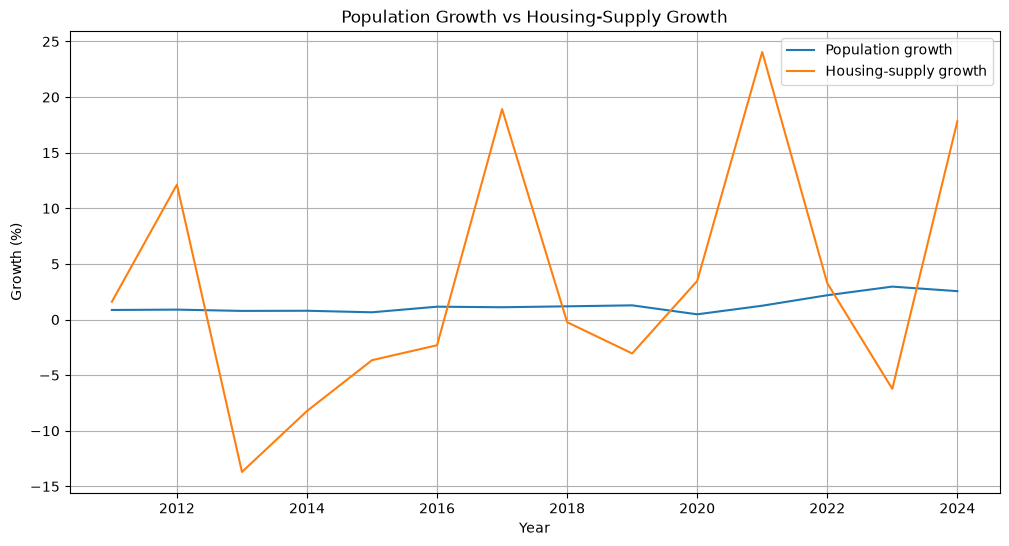

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    national_growth["year"],
    national_growth["population_growth_pct"],
    label="Population growth"
)

plt.plot(
    national_growth["year"],
    national_growth["housing_supply_growth_pct"],
    label="Housing-supply growth"
)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("Population Growth vs Housing-Supply Growth")
plt.legend()
plt.grid(True)

plt.show()

In [79]:
regional_supply_demand = (
    housing_demand_supply
    .groupby("region")["supply_demand_growth_gap_pct"]
    .mean()
    .sort_values(ascending=False)
)

In [80]:
regional_supply_demand

region
Prince Edward Island         5.445607
Alberta                      3.780485
Nova Scotia                  3.749368
New Brunswick                3.065456
British Columbia             2.942898
Manitoba                     1.016011
Ontario                      0.842649
Quebec                       0.037814
Saskatchewan                -0.709315
Newfoundland and Labrador   -1.782530
Name: supply_demand_growth_gap_pct, dtype: float64

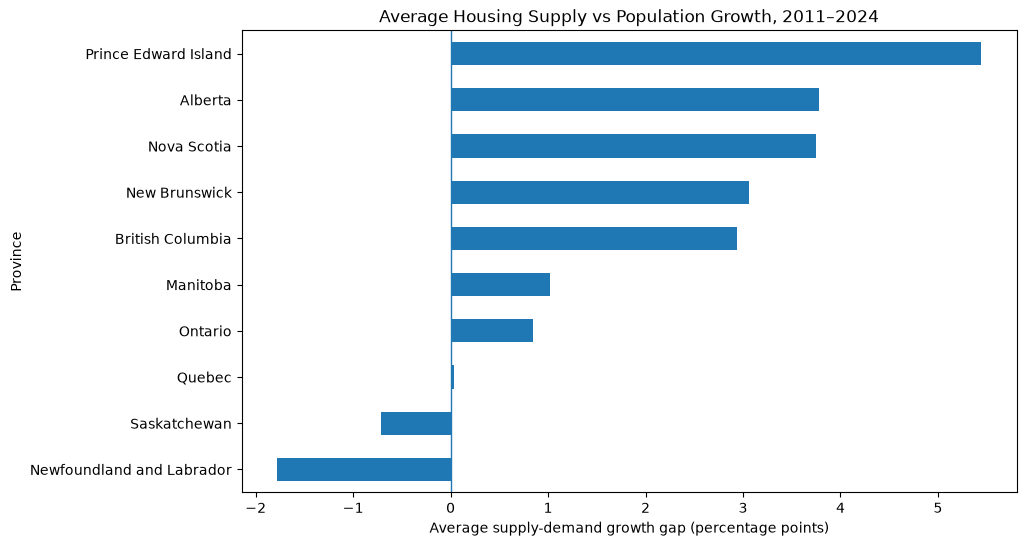

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

regional_supply_demand.sort_values().plot(kind="barh")

plt.xlabel("Average supply-demand growth gap (percentage points)")
plt.ylabel("Province")
plt.title("Average Housing Supply vs Population Growth, 2011–2024")

plt.axvline(0, linewidth=1)

plt.show()

# 6. Policy Rate Relationship

In [82]:
policy_rate = pd.read_sql(
    """
    SELECT
        EXTRACT(YEAR FROM date)::INTEGER AS year,
        AVG(policy_rate) AS policy_rate
    FROM policy_rate
    WHERE date >= '2010-01-01'
      AND date < '2025-01-01'
    GROUP BY EXTRACT(YEAR FROM date)
    ORDER BY year
    """,
    engine
)

In [83]:
policy_rate

,year,policy_rate
0,2010,0.590996
1,2011,1.000000
2,2012,1.000000
3,2013,1.000000
4,2014,1.000000
5,2015,0.646552
6,2016,0.500000
7,2017,0.698077
8,2018,1.404215
9,2019,1.750000


In [84]:
national_housing = (
    housing_demand_supply
    .groupby("year")["housing_starts_saar"]
    .sum()
    .reset_index()
)

In [85]:
national_housing["housing_supply_growth_pct"] = (
    national_housing["housing_starts_saar"]
    .pct_change()
    * 100
)

In [86]:
policy_housing = pd.merge(
    national_housing,
    policy_rate,
    on="year",
    how="inner"
)

In [87]:
policy_housing.head()

,year,housing_starts_saar,housing_supply_growth_pct,policy_rate
0,2010,191564.08,NaN,0.590996
1,2011,193387.24,0.951723,1.000000
2,2012,215411.00,11.388425,1.000000
3,2013,188031.41,-12.710395,1.000000
4,2014,189107.67,0.572383,1.000000


In [88]:
policy_housing.shape

(15, 4)

In [89]:
policy_housing.head(15)

,year,housing_starts_saar,housing_supply_growth_pct,policy_rate
0,2010,191564.08,NaN,0.590996
1,2011,193387.24,0.951723,1.000000
2,2012,215411.00,11.388425,1.000000
3,2013,188031.41,-12.710395,1.000000
4,2014,189107.67,0.572383,1.000000
5,2015,193597.50,2.374219,0.646552
6,2016,198168.24,2.360950,0.500000
7,2017,219975.57,11.004453,0.698077
8,2018,213571.19,-2.911405,1.404215
9,2019,208496.68,-2.376027,1.750000


### Policy rate vs Housing Supply 

In [90]:
policy_housing[
    ["policy_rate", "housing_supply_growth_pct"]
].corr()

,policy_rate,housing_supply_growth_pct
policy_rate,1.000000,-0.431323
housing_supply_growth_pct,-0.431323,1.000000


In [91]:
correlation = policy_housing[
    ["policy_rate", "housing_supply_growth_pct"]
].corr().loc[
    "policy_rate",
    "housing_supply_growth_pct"
]

correlation

np.float64(-0.4313225493428523)

#### correlation cofficient **-0.43** indicatres a weak negative relationship between housing supply and monetary policy.

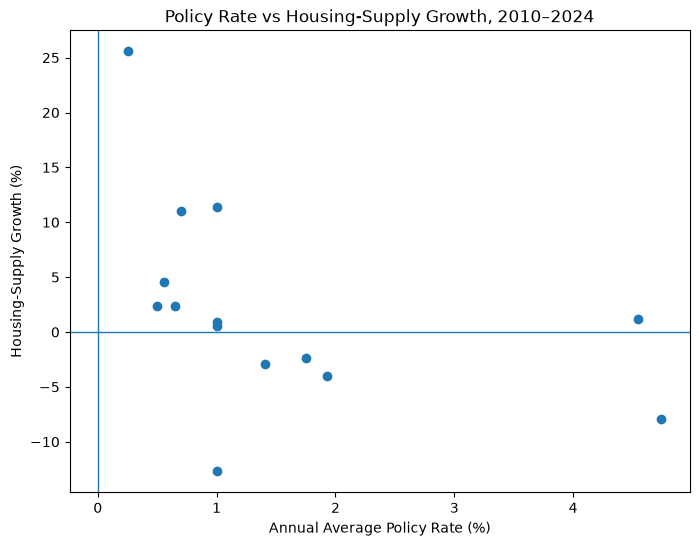

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    policy_housing["policy_rate"],
    policy_housing["housing_supply_growth_pct"]
)

plt.xlabel("Annual Average Policy Rate (%)")
plt.ylabel("Housing-Supply Growth (%)")
plt.title("Policy Rate vs Housing-Supply Growth, 2010–2024")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.show()

#### Relationship between Policy Rate and Housing Prices

In [93]:
national_nhpi = (
    affordability
    .groupby("year")["nhpi"]
    .mean()
    .reset_index()
)

In [94]:
national_nhpi["nhpi_growth_pct"] = (
    national_nhpi["nhpi"]
    .pct_change()
    * 100
)

In [95]:
policy_nhpi = pd.merge(
    national_nhpi,
    policy_rate,
    on="year",
    how="inner"
)

In [96]:
policy_nhpi

,year,nhpi,nhpi_growth_pct,policy_rate
0,2010,92.019167,NaN,0.590996
1,2011,93.982500,2.133613,1.000000
2,2012,95.420833,1.530427,1.000000
3,2013,96.976667,1.630496,1.000000
4,2014,97.734167,0.781116,1.000000
5,2015,98.247500,0.525234,0.646552
6,2016,99.323333,1.095024,0.500000
7,2017,101.030000,1.718294,0.698077
8,2018,101.842500,0.804217,1.404215
9,2019,101.914167,0.070370,1.750000


In [97]:
nhpi_policy_corr = policy_nhpi[
    ["policy_rate", "nhpi_growth_pct"]
].corr().loc[
    "policy_rate",
    "nhpi_growth_pct"
]

nhpi_policy_corr

np.float64(-0.30059176893045997)

#### The correlation coefficient **-0.3** indicates a very weak negative relationship between housing prices and the policy rate.

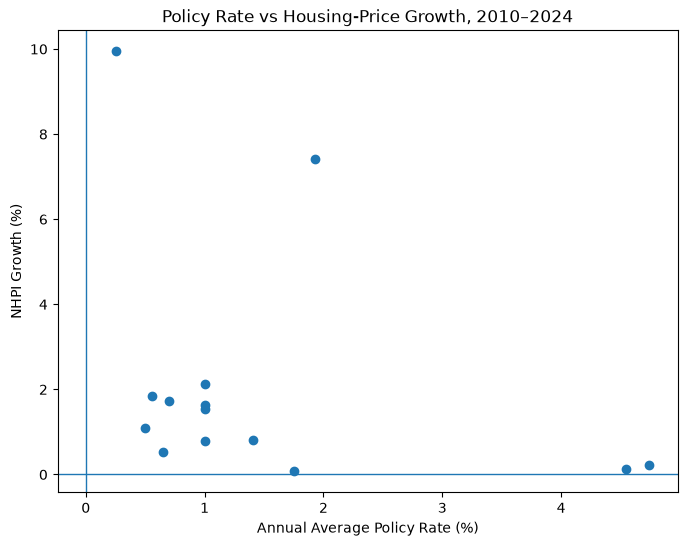

In [98]:
plt.figure(figsize=(8, 6))

plt.scatter(
    policy_nhpi["policy_rate"],
    policy_nhpi["nhpi_growth_pct"]
)

plt.xlabel("Annual Average Policy Rate (%)")
plt.ylabel("NHPI Growth (%)")
plt.title("Policy Rate vs Housing-Price Growth, 2010–2024")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.show()

#### Merge Dataset 

In [99]:
ca_housing_analysis_df = (
    policy_nhpi[
        ["year", "nhpi", "nhpi_growth_pct", "policy_rate"]
    ]
    .merge(
        policy_housing[
            ["year", "housing_starts_saar", "housing_supply_growth_pct"]
        ],
        on="year",
        how="inner"
    )
    .merge(
        national_growth[
            ["year", "population_growth_pct"]
        ],
        on="year",
        how="inner"
    )
)

In [100]:
ca_housing_analysis_df.shape

(15, 7)

In [101]:
ca_housing_analysis_df.isna().sum()

year                         0
nhpi                         0
nhpi_growth_pct              1
policy_rate                  0
housing_starts_saar          0
housing_supply_growth_pct    1
population_growth_pct        1
dtype: int64

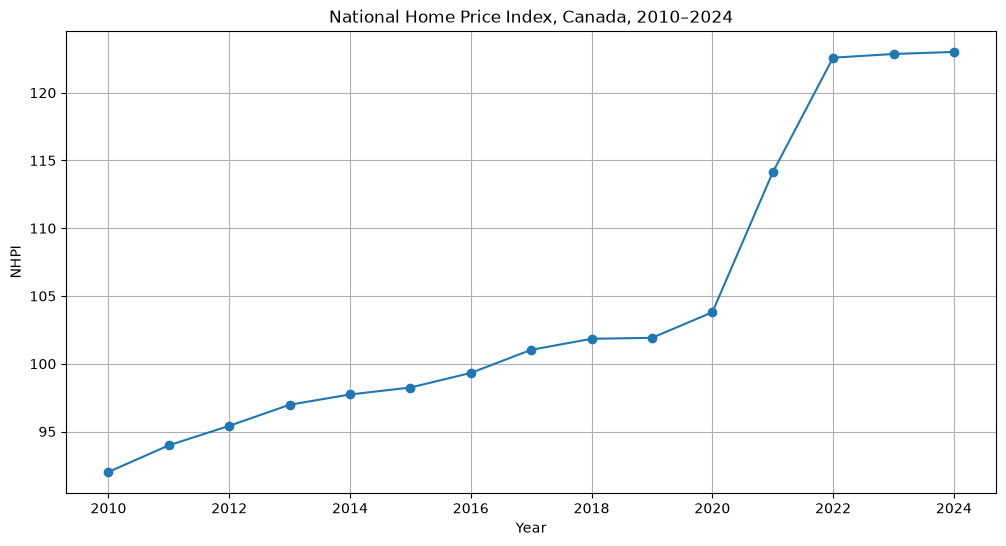

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["nhpi"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("NHPI")
plt.title("National Home Price Index, Canada, 2010–2024")
plt.grid(True)

plt.show()

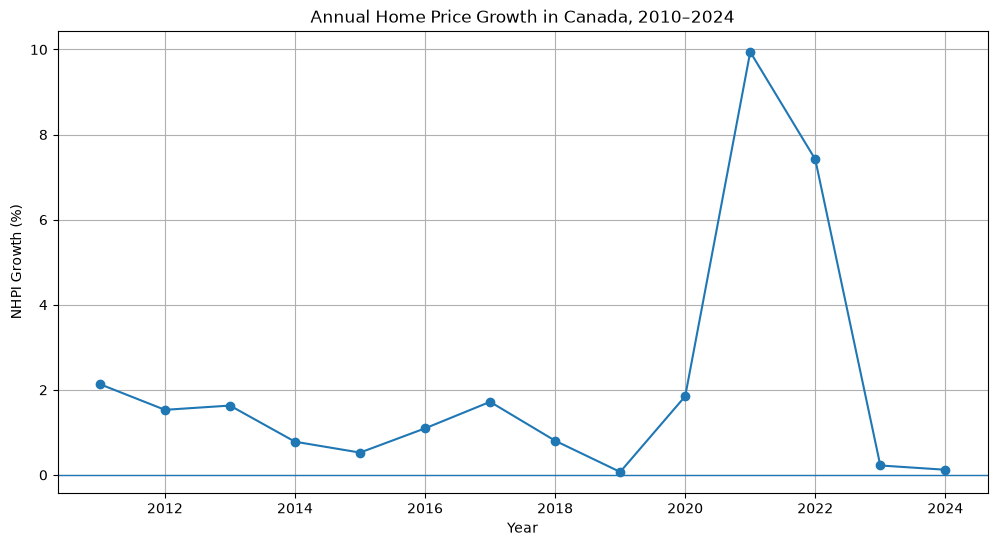

In [103]:
plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["nhpi_growth_pct"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("NHPI Growth (%)")
plt.title("Annual Home Price Growth in Canada, 2010–2024")
plt.grid(True)

plt.show()

In [104]:
national_income = (
    affordability
    .groupby("year")["income_growth_pct"]
    .mean()
    .reset_index()
)

In [105]:
ca_housing_analysis_df = ca_housing_analysis_df.merge(
    national_income,
    on="year",
    how="left"
)

In [106]:
ca_housing_analysis_df.columns

Index(['year', 'nhpi', 'nhpi_growth_pct', 'policy_rate', 'housing_starts_saar',
       'housing_supply_growth_pct', 'population_growth_pct',
       'income_growth_pct'],
      dtype='str')

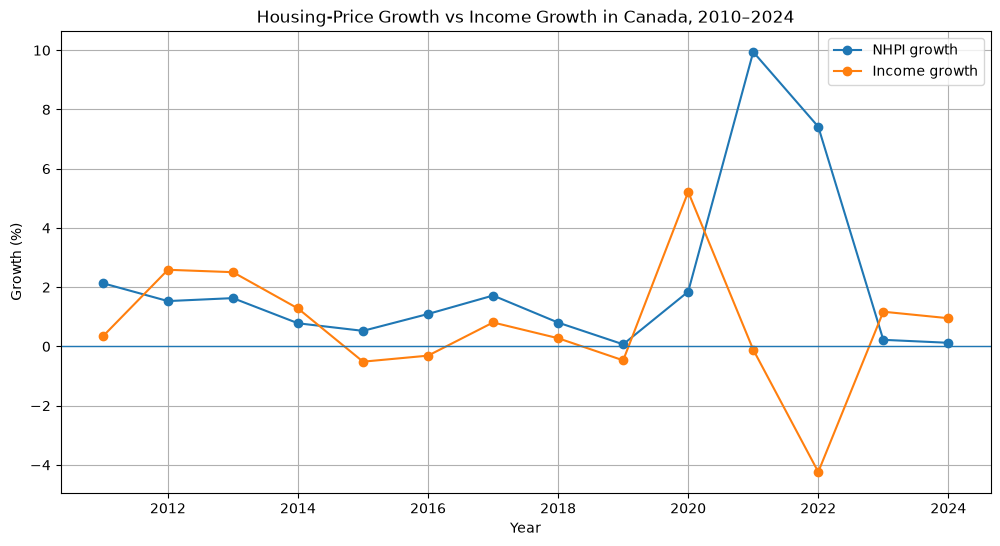

In [107]:
plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["nhpi_growth_pct"],
    marker="o",
    label="NHPI growth"
)

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["income_growth_pct"],
    marker="o",
    label="Income growth"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("Housing-Price Growth vs Income Growth in Canada, 2010–2024")
plt.legend()
plt.grid(True)

plt.show()

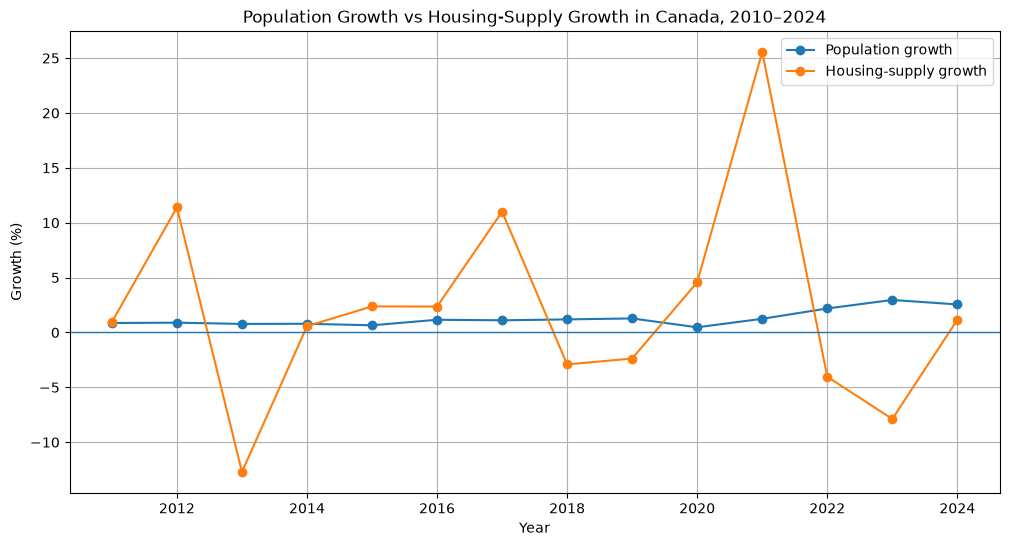

In [108]:
plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["population_growth_pct"],
    marker="o",
    label="Population growth"
)

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["housing_supply_growth_pct"],
    marker="o",
    label="Housing-supply growth"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("Population Growth vs Housing-Supply Growth in Canada, 2010–2024")
plt.legend()
plt.grid(True)

plt.show()

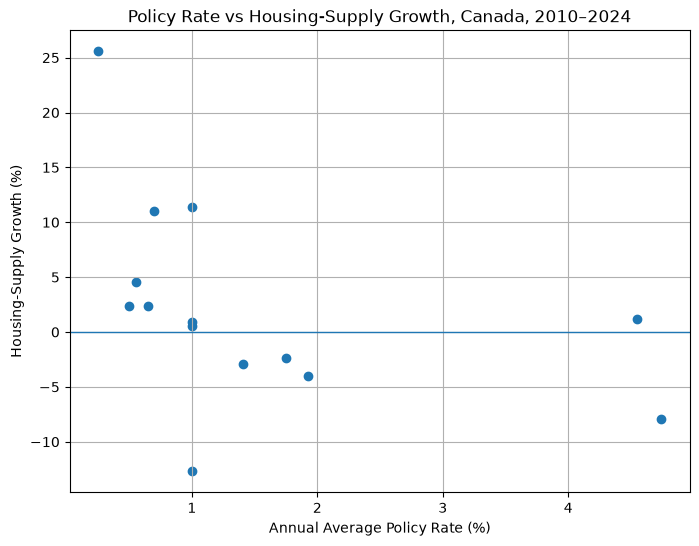

In [109]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ca_housing_analysis_df["policy_rate"],
    ca_housing_analysis_df["housing_supply_growth_pct"]
)

plt.xlabel("Annual Average Policy Rate (%)")
plt.ylabel("Housing-Supply Growth (%)")
plt.title("Policy Rate vs Housing-Supply Growth, Canada, 2010–2024")

plt.axhline(0, linewidth=1)
plt.grid(True)

plt.show()

#### R1 - How did housing prices change?

In [110]:
nhpi_change = (
    (ca_housing_analysis_df["nhpi"].iloc[-1]
     / ca_housing_analysis_df["nhpi"].iloc[0]
     - 1)
    * 100
)

nhpi_change

np.float64(33.67504958206171)

In [111]:
canada_income = (
    affordability[
        affordability["region"] == "Canada"
    ][
        ["year", "median_after_tax_income"]
    ]
    .sort_values("year")
    .copy()
)

In [112]:
canada_income["income_growth_pct"] = (
    canada_income["median_after_tax_income"]
    .pct_change()
    * 100
)

In [113]:
affordability["region"].unique()

<StringArray>
[                  'Alberta',          'British Columbia',
                  'Manitoba',             'New Brunswick',
 'Newfoundland and Labrador',               'Nova Scotia',
                   'Ontario',      'Prince Edward Island',
                    'Quebec',              'Saskatchewan']
Length: 10, dtype: str

In [114]:
canada_income = (
    income[
        income["region"] == "Canada"
    ][
        ["year", "median_after_tax_income"]
    ]
    .sort_values("year")
    .copy()
)

In [115]:
income["canada"]

KeyError: 'canada'

In [ ]:
%whos DataFrame

Variable                  Type         Data/Info
------------------------------------------------
affordability             DataFrame    Shape: (150, 7)
ca_housing_analysis_df    DataFrame    Shape: (15, 8)
canada                    DataFrame    Shape: (81, 7)
canada_income             DataFrame    Shape: (0, 2)
canada_nhpi               DataFrame    Shape: (81, 4)
coverage                  DataFrame    Shape: (11, 8)
df                        DataFrame    Shape: (841, 7)
housing_demand_supply     DataFrame    Shape: (150, 7)
housing_supply            DataFrame    Shape: (150, 4)
income                    DataFrame    Shape: (150, 4)
missing_summary           DataFrame    Shape: (7, 2)
national_growth           DataFrame    Shape: (15, 3)
national_housing          DataFrame    Shape: (15, 3)
national_income           DataFrame    Shape: (15, 2)
national_nhpi             DataFrame    Shape: (15, 3)
nhpi_analysis             DataFrame    Shape: (841, 4)
policy_housing            DataFram

In [ ]:
canada.head

<bound method NDFrame.head of      year  region        nhpi  median_after_tax_income  population  \
0    1946  Canada         NaN                      NaN    12393000   
1    1947  Canada         NaN                      NaN    12646000   
2    1948  Canada         NaN                      NaN    12930000   
3    1949  Canada         NaN                      NaN    13548000   
4    1950  Canada         NaN                      NaN    13807000   
..    ...     ...         ...                      ...         ...   
788  2022  Canada  125.108333                  73900.0    39284491   
799  2023  Canada  124.816667                  75100.0    40467722   
810  2024  Canada  124.666667                  75500.0    41494132   
821  2025  Canada  123.316667                      NaN    41575585   
832  2026  Canada  121.233333                      NaN    41417056   

     housing_starts_saar  policy_rate  
0                    NaN          NaN  
1                    NaN          NaN  
2        

In [ ]:
canada_income = (
    canada[
        ["year", "median_after_tax_income"]
    ]
    .sort_values("year")
    .copy()
)

In [ ]:
canada_income.head()

,year,median_after_tax_income
0,1946,NaN
1,1947,NaN
2,1948,NaN
3,1949,NaN
4,1950,NaN


In [ ]:
canada_income.tail()

,year,median_after_tax_income
788,2022,73900.0
799,2023,75100.0
810,2024,75500.0
821,2025,NaN
832,2026,NaN


In [ ]:
canada_income = canada_income[
    canada_income["year"].between(2010, 2024)
].copy()

In [ ]:
canada_income.shape

(15, 2)

In [ ]:
canada_income["income_growth_pct"] = (
    canada_income["median_after_tax_income"]
    .pct_change()
    * 100
)

In [ ]:
canada_income

,year,median_after_tax_income,income_growth_pct
656,2010,67500.0,NaN
667,2011,67200.0,-0.444444
678,2012,69100.0,2.827381
689,2013,69500.0,0.578871
700,2014,71100.0,2.302158
711,2015,70900.0,-0.281294
722,2016,70900.0,0.000000
733,2017,72700.0,2.538787
744,2018,72700.0,0.000000
755,2019,72500.0,-0.275103


In [ ]:
income_change = (
    (
        canada_income.loc[
            canada_income["year"] == 2024,
            "median_after_tax_income"
        ].iloc[0]
        /
        canada_income.loc[
            canada_income["year"] == 2010,
            "median_after_tax_income"
        ].iloc[0]
        - 1
    )
    * 100
)

income_change

np.float64(11.851851851851848)

In [ ]:
affordability_difference = nhpi_change - income_change

affordability_difference

np.float64(21.823197730209863)

In [ ]:
relative_growth = nhpi_change / income_change

relative_growth

np.float64(2.8413323084864577)

In [ ]:
canada_population = (
    canada[
        ["year", "population"]
    ]
    .sort_values("year")
    .copy()
)

In [ ]:
canada_population = canada_population[
    canada_population["year"].between(2010, 2024)
].copy()

In [ ]:
canada_population

,year,population
656,2010,34132531
667,2011,34457713
678,2012,34834973
689,2013,35209597
700,2014,35555305
711,2015,35823591
722,2016,36257421
733,2017,36722075
744,2018,37259485
755,2019,37828162


In [ ]:
population_change = (
    (
        canada_population.loc[
            canada_population["year"] == 2024,
            "population"
        ].iloc[0]
        /
        canada_population.loc[
            canada_population["year"] == 2010,
            "population"
        ].iloc[0]
        - 1
    )
    * 100
)

population_change

np.float64(21.567697396949548)

In [ ]:
housing_supply_change = (
    (
        ca_housing_analysis_df.loc[
            ca_housing_analysis_df["year"] == 2024,
            "housing_starts_saar"
        ].iloc[0]
        /
        ca_housing_analysis_df.loc[
            ca_housing_analysis_df["year"] == 2010,
            "housing_starts_saar"
        ].iloc[0]
        - 1
    )
    * 100
)

housing_supply_change

np.float64(27.791791655304053)

In [ ]:
housing_demand_supply.head()

,year,region,population,population_growth_pct,housing_starts_saar,housing_supply_growth_pct,supply_demand_growth_gap_pct
0,2010,Alberta,3747235,NaN,27378.75,NaN,NaN
1,2011,Alberta,3805071,1.543431,25543.17,-6.704397,-8.247828
2,2012,Alberta,3897746,2.435566,33285.00,30.308807,27.873241
3,2013,Alberta,4008421,2.839462,36111.83,8.492805,5.653343
4,2014,Alberta,4103702,2.377021,40563.67,12.327927,9.950906


In [ ]:
regional_supply_gap = (
    housing_demand_supply
    .groupby("region")["supply_demand_growth_gap_pct"]
    .mean()
    .sort_values(ascending=False)
)

regional_supply_gap

region
Prince Edward Island         5.445607
Alberta                      3.780485
Nova Scotia                  3.749368
New Brunswick                3.065456
British Columbia             2.942898
Manitoba                     1.016011
Ontario                      0.842649
Quebec                       0.037814
Saskatchewan                -0.709315
Newfoundland and Labrador   -1.782530
Name: supply_demand_growth_gap_pct, dtype: float64

In [ ]:
positive_gap = (regional_supply_gap > 0).sum()
negative_gap = (regional_supply_gap < 0).sum()

positive_gap, negative_gap

(np.int64(8), np.int64(2))

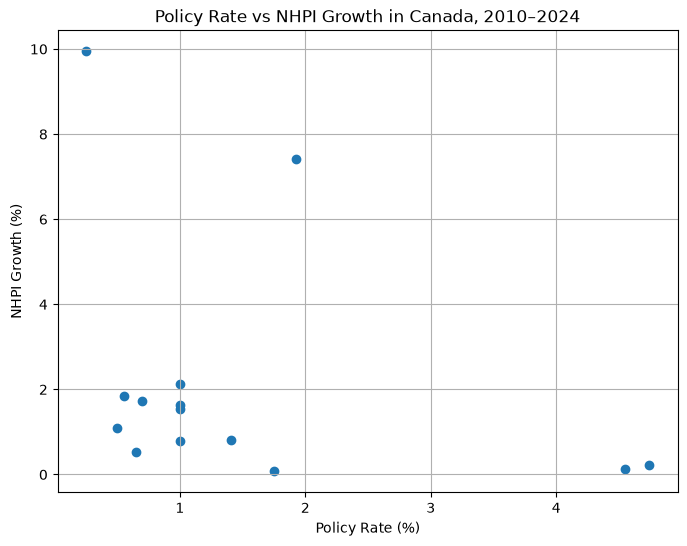

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ca_housing_analysis_df["policy_rate"],
    ca_housing_analysis_df["nhpi_growth_pct"]
)

plt.xlabel("Policy Rate (%)")
plt.ylabel("NHPI Growth (%)")
plt.title("Policy Rate vs NHPI Growth in Canada, 2010–2024")
plt.grid(True)

plt.show()

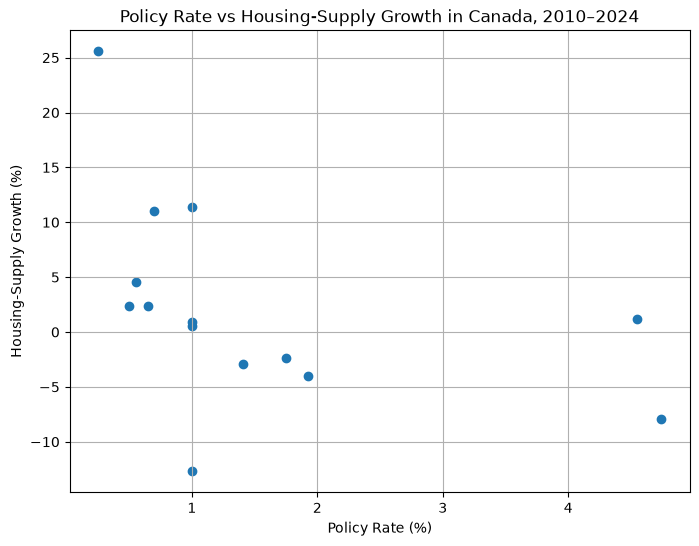

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ca_housing_analysis_df["policy_rate"],
    ca_housing_analysis_df["housing_supply_growth_pct"]
)

plt.xlabel("Policy Rate (%)")
plt.ylabel("Housing-Supply Growth (%)")
plt.title("Policy Rate vs Housing-Supply Growth in Canada, 2010–2024")
plt.grid(True)

plt.show()

In [ ]:
supply_population_difference = (
    housing_supply_change - population_change
)

supply_population_difference

np.float64(6.224094258354505)

In [ ]:
key_findings = pd.DataFrame({
    "Metric": [
        "NHPI change, 2010–2024",
        "Median after-tax income change, 2010–2024",
        "NHPI growth relative to income growth",
        "Population change, 2010–2024",
        "Housing starts change, 2010–2024",
        "Housing supply growth relative to population",
        "Provinces with positive supply-demand gap",
        "Provinces with negative supply-demand gap",
        "Policy rate vs housing-supply growth",
        "Policy rate vs NHPI growth"
    ],
    "Result": [
        nhpi_change,
        income_change,
        relative_growth,
        population_change,
        housing_supply_change,
        supply_population_difference,
        positive_gap,
        negative_gap,
        -0.431322,
        -0.30059176893045997
    ]
})

key_findings

,Metric,Result
0,"NHPI change, 2010–2024",33.675050
1,"Median after-tax income change, 2010–2024",11.851852
2,NHPI growth relative to income growth,2.841332
3,"Population change, 2010–2024",21.567697
4,"Housing starts change, 2010–2024",27.791792
5,Housing supply growth relative to population,6.224094
6,Provinces with positive supply-demand gap,8.000000
7,Provinces with negative supply-demand gap,2.000000
8,Policy rate vs housing-supply growth,-0.431322
9,Policy rate vs NHPI growth,-0.300592


In [ ]:
key_findings.round(2)

,Metric,Result
0,"NHPI change, 2010–2024",33.68
1,"Median after-tax income change, 2010–2024",11.85
2,NHPI growth relative to income growth,2.84
3,"Population change, 2010–2024",21.57
4,"Housing starts change, 2010–2024",27.79
5,Housing supply growth relative to population,6.22
6,Provinces with positive supply-demand gap,8.00
7,Provinces with negative supply-demand gap,2.00
8,Policy rate vs housing-supply growth,-0.43
9,Policy rate vs NHPI growth,-0.30


In [ ]:
nhpi_highest = (
    ca_housing_analysis_df
    .nlargest(3, "nhpi_growth_pct")
    [["year", "nhpi_growth_pct"]]
)

nhpi_lowest = (
    ca_housing_analysis_df
    .nsmallest(3, "nhpi_growth_pct")
    [["year", "nhpi_growth_pct"]]
)

nhpi_highest, nhpi_lowest

(    year  nhpi_growth_pct
 11  2021         9.942276
 12  2022         7.417685
 1   2011         2.133613,
     year  nhpi_growth_pct
 9   2019         0.070370
 14  2024         0.122093
 13  2023         0.222296)

In [ ]:
population_highest = (
    ca_housing_analysis_df
    .nlargest(3, "population_growth_pct")
    [["year", "population_growth_pct"]]
)

population_lowest = (
    ca_housing_analysis_df
    .nsmallest(3, "population_growth_pct")
    [["year", "population_growth_pct"]]
)

population_highest, population_lowest

(    year  population_growth_pct
 13  2023               2.961572
 14  2024               2.552916
 12  2022               2.185689,
     year  population_growth_pct
 10  2020               0.470378
 5   2015               0.652825
 3   2013               0.776833)

In [ ]:
housing_supply_highest = (
    ca_housing_analysis_df
    .nlargest(3, "housing_supply_growth_pct")
    [["year", "housing_supply_growth_pct"]]
)

housing_supply_lowest = (
    ca_housing_analysis_df
    .nsmallest(3, "housing_supply_growth_pct")
    [["year", "housing_supply_growth_pct"]]
)

housing_supply_highest, housing_supply_lowest

(    year  housing_supply_growth_pct
 11  2021                  25.560188
 2   2012                  11.388425
 7   2017                  11.004453,
     year  housing_supply_growth_pct
 3   2013                 -12.710395
 13  2023                  -7.882553
 12  2022                  -4.034702)

In [ ]:
ca_housing_analysis_df["year"] = (
    ca_housing_analysis_df["year"].astype(int)
)

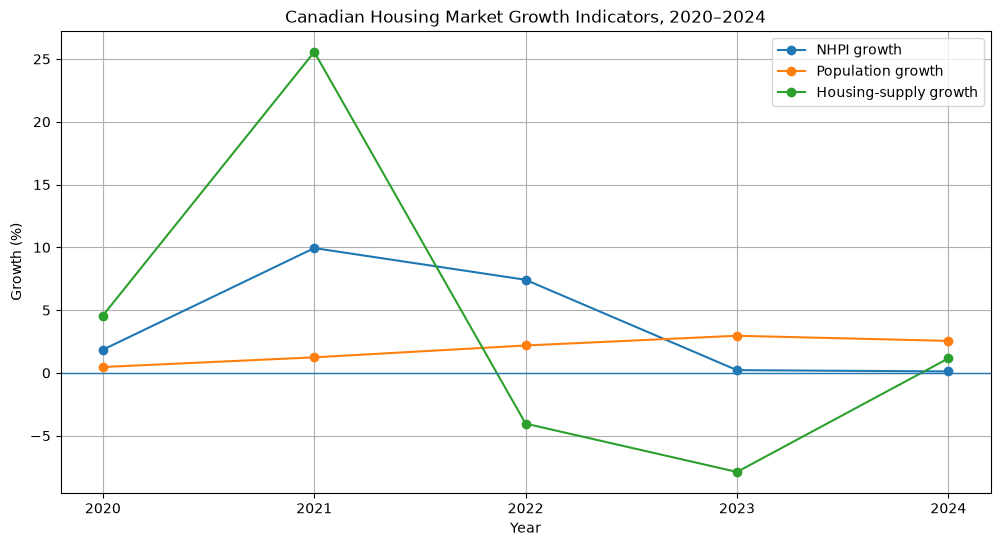

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    recent_period["year"],
    recent_period["nhpi_growth_pct"],
    marker="o",
    label="NHPI growth"
)

plt.plot(
    recent_period["year"],
    recent_period["population_growth_pct"],
    marker="o",
    label="Population growth"
)

plt.plot(
    recent_period["year"],
    recent_period["housing_supply_growth_pct"],
    marker="o",
    label="Housing-supply growth"
)

plt.xticks(recent_period["year"])

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("Canadian Housing Market Growth Indicators, 2020–2024")
plt.legend()
plt.grid(True)

plt.show()